In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle

# Notebook description

* This Notebook generates simulated price/temperature data to use in the thesis.
* We will discuss with the student how many days (n_days) and horizons (n_horizons) are required.
* The simulated results are stored in a dictionary (sims_dict)
* For conveniance, after generating the data the student can save it in a pickle file useing the code snippet below.

In [16]:

np.random.seed(42)

# ============================================================
# 1. SETUP
# ============================================================

n_days = 10
n_paths = 500
n_horizons = 720  # 365*24

asof_dates = pd.date_range("2020-01-01", periods=n_days, freq="D")
hours = np.arange(1, n_horizons + 1)
path_cols = [f"path_{i}" for i in range(1, n_paths + 1)]

series_names = ["price", "temp"]

sims_dict = {}
realized_dict = {s: pd.DataFrame(index=asof_dates, columns=hours, dtype=float)
                 for s in series_names}

# ============================================================
# 2. FAKE JOINT SIMULATIONS (price & temperature)
# ============================================================

base_price = 50.0
amp_price_day = 10.0          # intraday amplitude
amp_price_year = 5.0          # yearly amplitude (keep modest)

base_temp = 10.0
amp_temp_day = 8.0            # intraday amplitude
amp_temp_year = 12.0          # yearly amplitude (bigger seasonal swing)

sigma_price = 5.0
sigma_temp = 3.0
rho = 0.5

cov = np.array([
    [sigma_price**2, rho * sigma_price * sigma_temp],
    [rho * sigma_price * sigma_temp, sigma_temp**2]
])

# Precompute Cholesky for fast correlated shocks
L = np.linalg.cholesky(cov)  # cov = L @ L.T

for asof in asof_dates:
    # Build an hourly datetime index for the horizon starting at asof
    dt_index = pd.date_range(asof, periods=n_horizons, freq="h")

    # Intraday seasonality (hour of day)
    hod = dt_index.hour.values  # 0..23
    day_phase = 2 * np.pi * hod / 24.0

    # NEW: Yearly seasonality (day of year)
    doy = dt_index.dayofyear.values  # 1..365/366
    year_phase = 2 * np.pi * (doy - 1) / 365.0  # keep 365 for simplicity

    # Hourly means (shape: n_horizons,)
    mean_price = (
    base_price
    + amp_price_day * (
        0.8 * np.sin(day_phase - np.pi) +
        0.2 * np.sin(2 * (day_phase - np.pi))
    )
    + amp_price_year * np.cos(year_phase)
    )

    mean_temp = (
    base_temp
    - amp_temp_day * np.cos(2 * np.pi * (hod - 5) / 24.0)
    + amp_temp_year * np.cos(year_phase + np.pi)
    )

    # Draw all shocks at once: Z ~ N(0, I), then eps = Z @ L.T
    Z = np.random.normal(size=(n_horizons, n_paths, 2))            # iid
    eps = Z @ L.T                                                 # correlated

    sims_price = mean_price[:, None] + eps[:, :, 0]
    sims_temp  = mean_temp[:, None]  + eps[:, :, 1]

    # Realized values: one draw per hour (same distribution)
    Z_real = np.random.normal(size=(n_horizons, 2))
    eps_real = Z_real @ L.T
    realized_price = mean_price + eps_real[:, 0]
    realized_temp  = mean_temp  + eps_real[:, 1]

    realized_dict["price"].loc[asof, :] = realized_price
    realized_dict["temp"].loc[asof, :]  = realized_temp

    df_price = pd.DataFrame(sims_price, index=hours, columns=path_cols)
    df_temp  = pd.DataFrame(sims_temp,  index=hours, columns=path_cols)

    sims_dict[asof] = {"price": df_price, "temp": df_temp}


In [17]:
#Example output: Temperature
sims_dict[pd.Timestamp("2020-01-07 00:00:00")]['temp'].head()

,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,...,path_491,path_492,path_493,path_494,path_495,path_496,path_497,path_498,path_499,path_500
1,-0.162401,-0.638799,-3.132349,-5.001637,-5.735591,-1.679811,-2.978160,-1.155616,-7.882572,-4.182657,...,-1.279613,-1.197815,-9.576022,-0.786389,-6.003701,-2.983709,-4.307935,-6.492051,-4.033640,-4.975909
2,-10.287126,-3.588197,-8.408746,-13.872945,-1.846539,-5.060355,-7.196409,-10.705881,-7.353223,-6.343857,...,-2.941732,-7.701651,-6.199067,-3.143731,-1.258174,-8.206660,-8.079261,-2.103362,-6.325934,-2.777286
3,-12.391046,-7.035407,-10.643505,-9.896201,-11.020408,-10.441712,-8.101900,-6.025632,-5.306406,-7.342438,...,-4.807737,-9.883720,-7.664939,-12.418662,-7.301060,-9.520110,-0.906163,-6.686036,-9.098423,-10.095084
4,-11.878569,-11.079949,-4.702480,-10.220957,-12.226116,-6.384743,-7.694190,-13.316567,-4.172375,-8.882823,...,-11.453813,-7.856474,-8.267942,-4.269607,-6.065944,-16.321647,-8.428772,-11.225532,-13.792841,-13.179590
5,-9.697576,-8.371462,-13.846395,-13.442495,-10.574259,-10.413528,-7.500227,-11.838305,-9.203567,-8.937377,...,-4.486240,-10.044590,-10.909865,-9.002579,-9.436467,-14.758765,-5.241431,-8.419035,-12.557315,-15.750184


In [18]:
#Example output: Price
sims_dict[pd.Timestamp("2020-01-07 00:00:00")]['price'].head()

,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,...,path_491,path_492,path_493,path_494,path_495,path_496,path_497,path_498,path_499,path_500
1,58.503907,57.841083,56.458791,53.598735,48.462757,53.121239,53.531557,55.879205,50.214816,53.219726,...,63.657851,59.589300,53.876632,56.272017,53.821517,57.277121,60.705251,51.253713,53.984420,56.788744
2,54.168034,51.501891,56.184482,56.464136,55.397160,54.754335,53.025737,53.246422,51.336980,53.382051,...,59.877075,55.272729,57.601597,58.394362,57.732385,50.914435,54.523167,54.008458,61.926213,56.419244
3,52.461096,50.057114,52.962587,51.424024,44.292995,47.161877,53.549577,56.928473,60.121578,54.475899,...,55.750337,49.107648,52.430125,61.421924,51.314576,45.038816,55.403432,50.528384,47.476153,50.615832
4,44.526604,53.245600,50.999796,39.739285,47.741007,54.628830,50.284326,49.031056,52.718060,53.435175,...,43.082757,52.717644,57.042832,54.349825,54.605725,43.564196,52.560219,52.595617,45.952171,42.377964
5,58.041674,51.102043,44.999058,34.818869,52.719715,53.455690,48.020657,50.024681,42.835723,53.491135,...,57.448134,52.187292,48.629973,55.690895,53.878581,38.671080,55.682591,54.457163,41.062527,46.866689


**Save the simulated data**

In [19]:
# output_path = "sims_dict.pkl"

# with open(output_path, "wb") as f:
#     pickle.dump(sims_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    

**Re-load the saved data**

In [20]:
# with open("sims_dict.pkl", "rb") as f:
#     sims_dict_loaded = pickle.load(f)

In [21]:
# ============================================================
# STEP 1: DATA INSPECTION
# ============================================================

print("=== asof_dates ===")
print(f"type: {type(asof_dates)}")
print(f"length: {len(asof_dates)}")
print(f"first three: {asof_dates[:3]}")

print("\n=== sims_dict structure ===")
asof_example = asof_dates[0]
print(f"sims_dict keys_num: {len(sims_dict)}")
print(f"signal asof  keys: {list(sims_dict[asof_example].keys())}")

for s in series_names:
    df = sims_dict[asof_example][s]
    print(f"\n  series='{s}':")
    print(f"    type: {type(df)}")
    print(f"    shape: {df.shape}")
    print(f"    index (first 5): {df.index[:5].tolist()}")
    print(f"    columns (first 5): {df.columns[:5].tolist()}")
    print(f"     NaN: {df.isnull().any().any()}")

print("\n=== realized_dict structure ===")
for s in series_names:
    df = realized_dict[s]
    print(f"\n  series='{s}':")
    print(f"    type: {type(df)}")
    print(f"    shape: {df.shape}")
    print(f"    index (first 3): {df.index[:3].tolist()}")
    print(f"    columns (first 5): {df.columns[:5].tolist()}")
    print(f"    has NaN: {df.isnull().any().any()}")


 

=== asof_dates ===
type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
length: 10
first three: DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[ns]', freq='D')

=== sims_dict structure ===
sims_dict keys_num: 10
signal asof  keys: ['price', 'temp']

  series='price':
    type: <class 'pandas.core.frame.DataFrame'>
    shape: (720, 500)
    index (first 5): [1, 2, 3, 4, 5]
    columns (first 5): ['path_1', 'path_2', 'path_3', 'path_4', 'path_5']
     NaN: False

  series='temp':
    type: <class 'pandas.core.frame.DataFrame'>
    shape: (720, 500)
    index (first 5): [1, 2, 3, 4, 5]
    columns (first 5): ['path_1', 'path_2', 'path_3', 'path_4', 'path_5']
     NaN: False

=== realized_dict structure ===

  series='price':
    type: <class 'pandas.core.frame.DataFrame'>
    shape: (10, 720)
    index (first 3): [Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-02 00:00:00'), Timestamp('2020-01-03 00:00:00')]
    columns (first 5): [1, 2, 3, 4, 5]
 

In [22]:
# ============================================================
# STEP 2: single asof + single series  PIT on price
# ============================================================

asof_test = asof_dates[0]
s_test = "price"

sims     = sims_dict[asof_test][s_test].values   # (8760, 5000)
realized = realized_dict[s_test].loc[asof_test].values  # (8760,)

print(f"sims shape:     {sims.shape}")
print(f"realized shape: {realized.shape}")

# --- sort ---
sorted_sims = np.sort(sims, axis=1)  # (8760, 5000) 
print(f"sorted_sims shape: {sorted_sims.shape}")

# ---  searchsorted ---
n_horizons, n_paths = sims.shape # (8760, 5000)

ranks = np.array([
    np.searchsorted(sorted_sims[i], realized[i], side='right')for i in range(n_horizons)
], dtype=float)  # (8760,)

print(f"\nranks shape: {ranks.shape}")
print(f"ranks first 5: {ranks[:5]}")
print(f"ranks min: {ranks.min()},  max: {ranks.max()}")
print(f"ranks should be in [0, {n_paths}] : {(ranks >= 0).all() and (ranks <= n_paths).all()}")

# --- Randomization ---
N = sims.shape[1]  # not n_paths
u = np.random.uniform(0.0, 1.0, size=ranks.shape)
pit_values = (ranks + u) / (N + 1.0)

# clip solely for numerical safety before norm.ppf
# PIT values are theoretically in (0,1) by construction
eps = 1e-6
pit_values = np.clip(pit_values, eps, 1 - eps)

print(f"\npit_values shape: {pit_values.shape}")
print(f"pit_values first 5: {np.round(pit_values[:5], 4)}")
print(f"pit_values min: {pit_values.min():.4f},  max: {pit_values.max():.4f}")
print(f"pit_values mean: {pit_values.mean():.4f}  (ideal value ≈ 0.5)")
print(f"pit_values std: {pit_values.std():.4f}  (ideal value ≈ {1/np.sqrt(12):.4f})")

sims shape:     (720, 500)
realized shape: (720,)
sorted_sims shape: (720, 500)

ranks shape: (720,)
ranks first 5: [150. 455. 126. 381. 494.]
ranks min: 0.0,  max: 500.0
ranks should be in [0, 500] : True

pit_values shape: (720,)
pit_values first 5: [0.3014 0.9091 0.2516 0.762  0.9863]
pit_values min: 0.0012,  max: 0.9995
pit_values mean: 0.5123  (ideal value ≈ 0.5)
pit_values std: 0.2830  (ideal value ≈ 0.2887)


In [23]:
# ============================================================
# STEP 3: all asof_dates × series_names
# ============================================================

pit_dict = {}

for s in series_names:
    print(f"\n series: '{s}' ...")
    
    horizon_index = sims_dict[asof_dates[0]][s].index  # (8760,)
    pit_matrix = pd.DataFrame(index=asof_dates, columns=horizon_index, dtype=float)

    for asof in asof_dates:
        sims     = sims_dict[asof][s].values                    # (8760, 5000)
        realized = realized_dict[s].loc[asof].values            # (8760,)

        n_horizons, n_paths = sims.shape
        sorted_sims = np.sort(sims, axis=1)

        ranks = np.array(
            [np.searchsorted(sorted_sims[i], realized[i], side='right') for i in range(n_horizons)], # side='right' to get rank in [0, n_paths]
            dtype=float
        )

        pit_values = (ranks + np.random.uniform(0.0, 1.0, size=ranks.shape)) / (n_paths + 1) 
        pit_values = np.clip(pit_values, 0.0, 1.0)

        pit_matrix.loc[asof] = pit_values

    pit_dict[s] = pit_matrix
    print(f"  pit_matrix shape: {pit_dict[s].shape}")
    print(f"  has NaN: {pit_dict[s].isnull().any().any()}")

print("\n=== Marginal PIT ===")
for s in series_names:
    pit_flat = pit_dict[s].values.flatten().astype(float)
    print(f"[{s}] mean: {pit_flat.mean():.4f},  std: {pit_flat.std():.4f}")


 series: 'price' ...


  pit_matrix shape: (10, 720)
  has NaN: False

 series: 'temp' ...
  pit_matrix shape: (10, 720)
  has NaN: False

=== Marginal PIT ===
[price] mean: 0.4971,  std: 0.2865
[temp] mean: 0.4976,  std: 0.2875


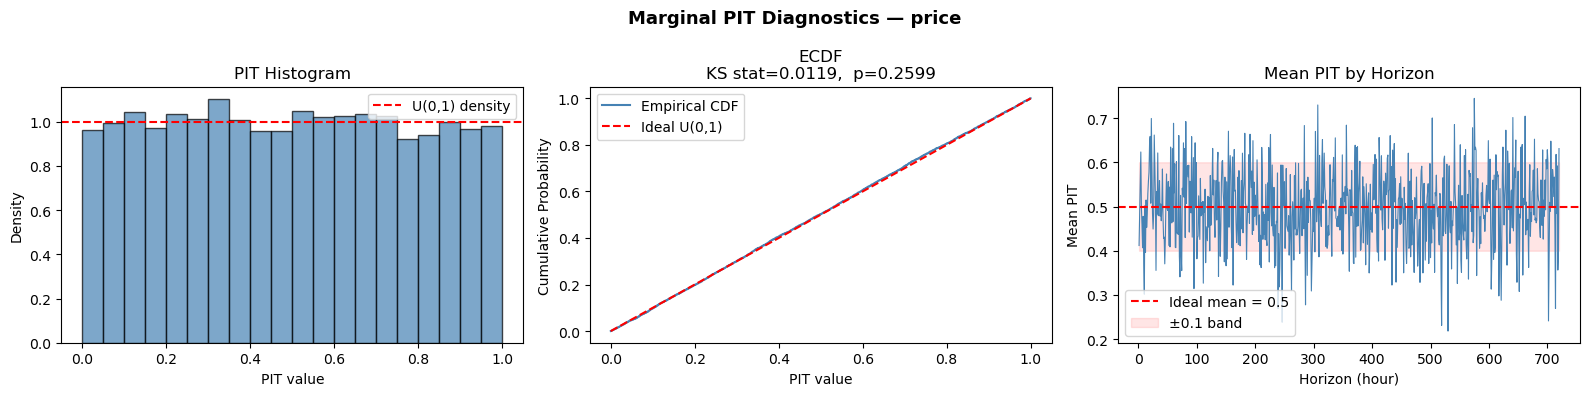

[price] PIT report
  KS statistic:  0.0119
  KS p-value: 0.2599  ✓ do not reject uniformity
  mean:       0.4971  (ideal value 0.5)
  std:        0.2865  (ideal value 0.2887)



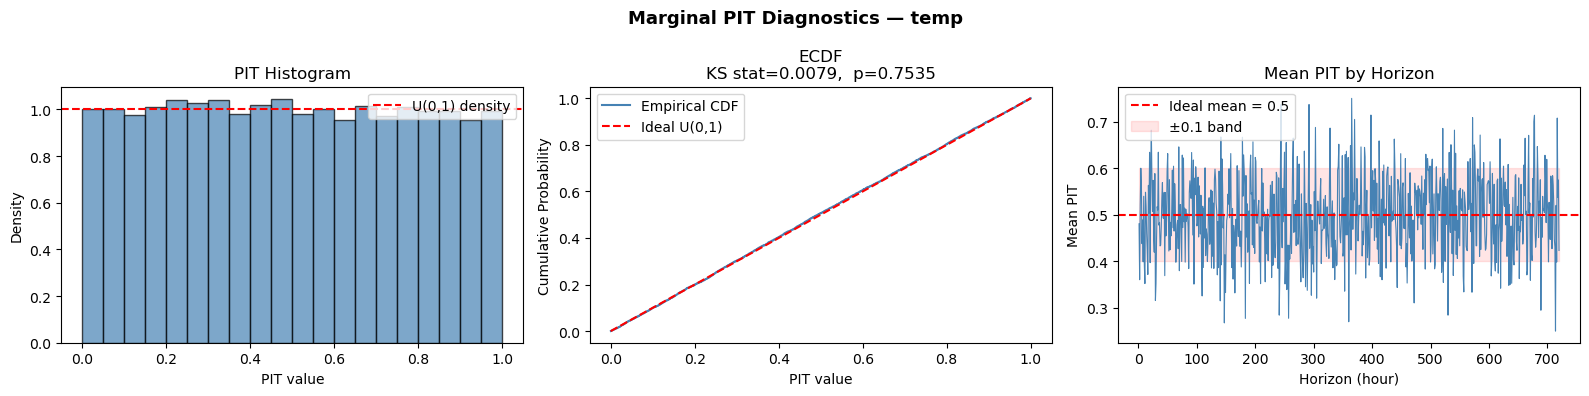

[temp] PIT report
  KS statistic:  0.0079
  KS p-value: 0.7535  ✓ do not reject uniformity
  mean:       0.4976  (ideal value 0.5)
  std:        0.2875  (ideal value 0.2887)



In [24]:
# ============================================================
# STEP 4: diagnostics plots + KS test
# ============================================================

for s in series_names:
    pit_flat = pit_dict[s].values.flatten().astype(float)
    ks_stat, ks_p = stats.kstest(pit_flat, 'uniform') 

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Marginal PIT Diagnostics — {s}", fontsize=13, fontweight='bold')

    # --- plot 1: Histogram ---
    axes[0].hist(pit_flat, bins=20, edgecolor='k', density=True, alpha=0.7, color='steelblue')
    axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='U(0,1) density')
    axes[0].set_title("PIT Histogram")
    axes[0].set_xlabel("PIT value")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # --- plot 2: ECDF ---
    pit_sorted = np.sort(pit_flat)
    n = len(pit_sorted)
    axes[1].step(pit_sorted, np.arange(1, n + 1) / n, where='post',
                 color='steelblue', label='Empirical CDF')
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Ideal U(0,1)')
    axes[1].set_title(f"ECDF\nKS stat={ks_stat:.4f},  p={ks_p:.4f}")
    axes[1].set_xlabel("PIT value")
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].legend()

    # --- plot 3: every Horizon  PIT mean ---
    pit_mean_by_horizon = pit_dict[s].mean(axis=0).astype(float)
    axes[2].plot(pit_dict[s].columns, pit_mean_by_horizon, color='steelblue', linewidth=0.8) 
    axes[2].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Ideal mean = 0.5')
    axes[2].fill_between(pit_dict[s].columns, 0.4, 0.6, alpha=0.1, color='red', label='±0.1 band')
    axes[2].set_title("Mean PIT by Horizon")
    axes[2].set_xlabel("Horizon (hour)")
    axes[2].set_ylabel("Mean PIT")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # --- conclusion ---
    print(f"{'='*45}")
    print(f"[{s}] PIT report")
    print(f"  KS statistic:  {ks_stat:.4f}")
    print(f"  KS p-value: {ks_p:.4f}  {'✓ do not reject uniformity' if ks_p > 0.05 else '✗ reject uniformity'}")
    print(f"  mean:       {pit_flat.mean():.4f}  (ideal value 0.5)")
    print(f"  std:        {pit_flat.std():.4f}  (ideal value {1/np.sqrt(12):.4f})")
    print(f"{'='*45}\n")

In [27]:
from scipy.stats import anderson, norm

# ============================================================
# STEP 5: Anderson-Darling Test for Uniformity on Gaussianized PIT
# ============================================================

for s in series_names:
    pit_flat = pit_dict[s].values.flatten().astype(float)
    pit_flat = pit_flat[~np.isnan(pit_flat)]  # Remove NaN if any
    
    if len(pit_flat) < 10:  # AD need sufficient samples
        print(f"[{s}] samll sample size ({len(pit_flat)})，no AD test")
        continue
    
   
    # extreme PIT Value can lead to inf/nan after transformation, so we clip them to a reasonable range
    pit_clipped = np.clip(pit_flat, 1e-6, 1 - 1e-6)
    z = norm.ppf(pit_clipped)
    
    # AD test for normality on transformed values
    ad_result = anderson(z, dist='norm')
    
    print(f"{'='*60}")
    print(f"[{s}] Anderson-Darling Test for Uniformity (on Gaussianized PIT)")
    print(f" AD statistic: {ad_result.statistic:.4f}")
    print(f" sample(valide): {len(z)}")
    print()
    print(f" {'significance':<12} {'critical value':<12} {'conclusion'}")
    print(f" {'-'*45}")
    for sig, cv in zip(ad_result.significance_level, ad_result.critical_values):
        reject = ad_result.statistic > cv
        conclusion = "✗ reject uniformity (after transform)" if reject else "✓ do not reject uniformity"
        print(f" {sig:<12.1f} {cv:<12.4f} {conclusion}")
    print(f"{'='*60}\n")

[price] Anderson-Darling Test for Uniformity (on Gaussianized PIT)
 AD statistic: 0.2531
 sample(valide): 7200

 significance critical value conclusion
 ---------------------------------------------
 15.0         0.5760       ✓ do not reject uniformity
 10.0         0.6560       ✓ do not reject uniformity
 5.0          0.7870       ✓ do not reject uniformity
 2.5          0.9170       ✓ do not reject uniformity
 1.0          1.0910       ✓ do not reject uniformity

[temp] Anderson-Darling Test for Uniformity (on Gaussianized PIT)
 AD statistic: 0.2219
 sample(valide): 7200

 significance critical value conclusion
 ---------------------------------------------
 15.0         0.5760       ✓ do not reject uniformity
 10.0         0.6560       ✓ do not reject uniformity
 5.0          0.7870       ✓ do not reject uniformity
 2.5          0.9170       ✓ do not reject uniformity
 1.0          1.0910       ✓ do not reject uniformity



In [30]:
# ============================================================
# STEP 6: Ljung-Box Test on PIT
# ============================================================

from scipy.stats import norm
from statsmodels.stats.diagnostic import acorr_ljungbox

# lags_to_test = [24, 168, 720]
lags_to_test = [24, 168, 336]
eps          = 1e-6
alpha        = 0.05
# min_obs      = lags_to_test[-1] + 10  # at least 730 valid observations to test up to lag 720
min_obs = 500  # relax the requirement for this simulated data, since we know it's well-behaved
lb_results = {s: [] for s in series_names}

for s in series_names:
    print(f"\n{'='*65}")
    print(f"[{s}] Ljung-Box Test on Gaussianized PIT (primary)")
    print(f"     and raw PIT (robustness check)")
    print(f"     Note: diagnostic evidence only;")
    print(f"     multiple tests reported without family-wise error control.")
    print(f"{'='*65}")

    for asof in asof_dates:

        # --- 1. Take the PIT sequence and remove non-finite values. ---
        pit_seq = pit_dict[s].loc[asof].values.astype(float) 
        mask    = np.isfinite(pit_seq) # Remove non-finite values (if any)
        pit_seq = pit_seq[mask]

        if len(pit_seq) < min_obs: 
            print(f"\n  as-of: {asof.date()} — Skip (Insufficient effective sample size:) {len(pit_seq)}）") # defensive check
            continue

        # --- 2. Construct a sequence (using the same clip only once).--- transformed using the inverse standard normal CDF, after clipping to (ε,1−ε)
        pit_clip = np.clip(pit_seq, eps, 1 - eps)
        z        = norm.ppf(pit_clip)   # primary：Gaussianized PIT
        pit_raw  = pit_clip             # PIT on original scale (clipped for numerical stability)


        # --- 3. compute lag ---
        lb_z_all   = acorr_ljungbox(z,       lags=lags_to_test, return_df=True) # primary test on Gaussianized PIT
        lb_pit_all = acorr_ljungbox(pit_raw, lags=lags_to_test, return_df=True) # robustness check on raw PIT

        print(f"\n  as-of: {asof.date()}  (n={len(pit_seq)})")
        print(f"  {'Lag (up to m)':<16} {'LB stat (z)':<14} {'p (z)':<12} {'p (PIT raw)':<14} {'conclusion'}")
        print(f"  {'-'*68}")

        for i, lag in enumerate(lags_to_test):
            # iloc to avoid version compatibility issues
            stat_z = lb_z_all['lb_stat'].iloc[i]
            p_z    = lb_z_all['lb_pvalue'].iloc[i]
            p_pit  = lb_pit_all['lb_pvalue'].iloc[i]

            reject     = p_z < alpha
            conclusion = "✗ Serial dependence" if reject else "✓ No serial dependence"

            print(f"  m={lag:<13} {stat_z:<14.4f} {p_z:<12.4f} {p_pit:<14.4f} {conclusion}")

            lb_results[s].append({
                'asof':      asof,
                'lag':       lag,
                'n_obs':     len(pit_seq),
                'lb_stat_z': stat_z,
                'p_z':       p_z,
                'p_pit':     p_pit,
                'reject_z':  reject
            })

# --- 4.  DataFrame ---
lb_results_df = {s: pd.DataFrame(lb_results[s]) for s in series_names}

# --- 5. report ---
print(f"\n{'='*65}")
print(f"Summary: Rejection rate across as-of dates (α={alpha})")
print(f"{'='*65}")
print(f"  {'Series':<10} {'Lag (up to m)':<16} {'Rejection Rate'}")
print(f"  {'-'*50}")

for s in series_names:
    df = lb_results_df[s]
    for lag in lags_to_test:
        subset = df[df['lag'] == lag]

        # empty subset
        if len(subset) == 0:
            print(f"  {s:<10} m={lag:<13} N/A (no valid as-of dates)") 
            continue

        reject_rate = subset['reject_z'].mean()
        n_reject    = subset['reject_z'].sum()
        n_total     = len(subset)
        print(f"  {s:<10} m={lag:<13} {reject_rate:.1%}  ({n_reject}/{n_total} as-of dates)")


[price] Ljung-Box Test on Gaussianized PIT (primary)
     and raw PIT (robustness check)
     Note: diagnostic evidence only;
     multiple tests reported without family-wise error control.

  as-of: 2020-01-01  (n=720)
  Lag (up to m)    LB stat (z)    p (z)        p (PIT raw)    conclusion
  --------------------------------------------------------------------
  m=24            37.2489        0.0413       0.0076         ✗ Serial dependence
  m=168           206.9990       0.0218       0.0025         ✗ Serial dependence
  m=336           415.2603       0.0020       0.0016         ✗ Serial dependence

  as-of: 2020-01-02  (n=720)
  Lag (up to m)    LB stat (z)    p (z)        p (PIT raw)    conclusion
  --------------------------------------------------------------------
  m=24            21.8515        0.5881       0.3041         ✓ No serial dependence
  m=168           165.3535       0.5433       0.3917         ✓ No serial dependence
  m=336           338.2502       0.4553       0.23

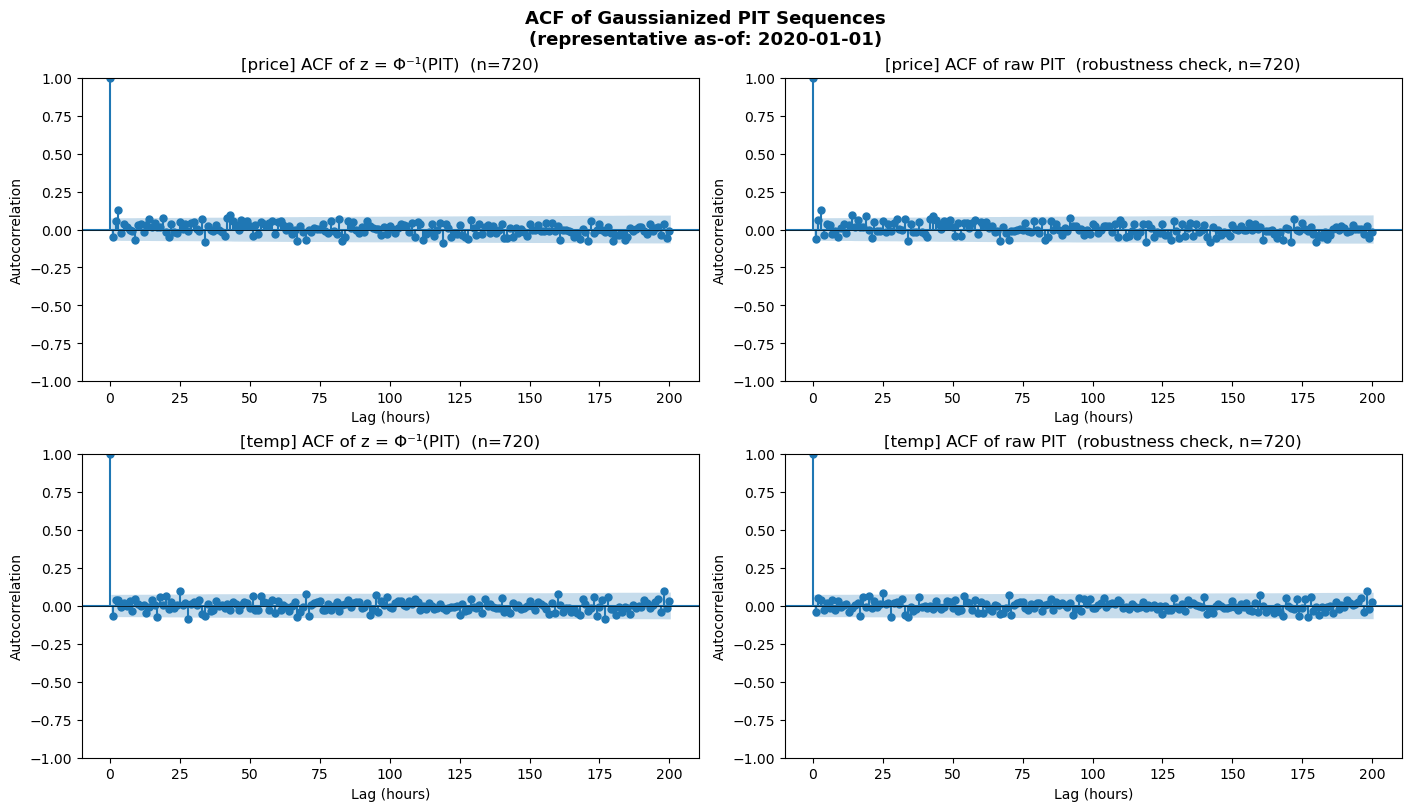

In [35]:
# ============================================================
# ACF of Gaussianized PIT Sequences
# ============================================================

import numpy as np
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# dynamic subplots based on number of series
n_series = len(series_names)
fig, axes = plt.subplots(
    n_series, 2,
    figsize=(14, 4 * n_series),
    constrained_layout=True      
)

# axes is 1D if n_series=1, so we ensure it's always 2D for consistent indexing
if n_series == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    "ACF of Gaussianized PIT Sequences\n"
    f"(representative as-of: {asof_dates[0].date()})",
    fontsize=13, fontweight='bold'
)

# choose the present asof date
asof = asof_dates[0]

for idx, s in enumerate(series_names):

    # ---  PIT sequence ---
    pit_seq  = pit_dict[s].loc[asof].values.astype(float)

    # --- Gaussianized PIT---
    pit_clip = np.clip(pit_seq, 1e-6, 1 - 1e-6)
    z        = norm.ppf(pit_clip)

    # NaN/inf can arise from extreme PIT values, so we filter them out for ACF plotting
    mask_z = np.isfinite(z)
    z      = z[mask_z]

    # --- Raw PIT（robustness check）---
    pit_raw      = pit_clip.copy()
    mask_pit     = np.isfinite(pit_raw)
    pit_raw      = pit_raw[mask_pit]

    # --- Gaussianized PIT ---
    plot_acf(
        z, lags=200, alpha=0.05,
        ax=axes[idx, 0],
        title=f"[{s}] ACF of z = Φ⁻¹(PIT)  "
              f"(n={len(z)})"
    )
    axes[idx, 0].set_xlabel("Lag (hours)")
    axes[idx, 0].set_ylabel("Autocorrelation")
    axes[idx, 0].axhline(0, color='black', linewidth=0.5)

    # --- Raw PIT（robustness）---
    plot_acf(
        pit_raw, lags=200, alpha=0.05,
        ax=axes[idx, 1],
        title=f"[{s}] ACF of raw PIT  "
              f"(robustness check, n={len(pit_raw)})"
    )
    axes[idx, 1].set_xlabel("Lag (hours)")
    axes[idx, 1].set_ylabel("Autocorrelation")
    axes[idx, 1].axhline(0, color='black', linewidth=0.5)

plt.show()

In [32]:
# ============================================================
# The μ/σ normalization of pooled simulated draws is used to give price and temp a fixed, model-inherent, 
# and consistent distance scale across as-of parameters, making the Energy Score comparable across different prediction windows.
# ============================================================

all_price_sims = np.concatenate([
    sims_dict[asof]['price'].values.flatten()
    for asof in asof_dates
])
all_temp_sims = np.concatenate([
    sims_dict[asof]['temp'].values.flatten()
    for asof in asof_dates
])

mu_price  = float(np.mean(all_price_sims))
std_price = float(np.std(all_price_sims))
mu_temp   = float(np.mean(all_temp_sims))
std_temp  = float(np.std(all_temp_sims))

print(f"Standardization params (from pooled simulated draws):")
print(f"  price: μ={mu_price:.4f}, σ={std_price:.4f}")
print(f"  temp:  μ={mu_temp:.4f},  σ={std_temp:.4f}")

Standardization params (from pooled simulated draws):
  price: μ=54.6742, σ=7.6850
  temp:  μ=-1.2242,  σ=6.4335


In [36]:
# ============================================================
# STEP 8: Energy Score implementation
# ============================================================


# --- 8.2 core function ---
def energy_score(sims_price, sims_temp, real_price, real_temp,  
                 mu_p, std_p, mu_t, std_t,
                 M=500, R=5, seed=42):
    """
    Joint Energy Score for bivariate path forecasts.

    The joint forecast vector is defined as:
        x = (x^price_{1:H}, x^temp_{1:H}) ∈ R^{2H}
    Vectorization order is arbitrary under Euclidean norm.

    Standardization
    ---------------
    Both variables are standardized using parameters computed from
    a fixed reference set (pooled simulated draws across all as-of
    dates), ensuring scale comparability across evaluation windows
    and preventing the distance metric from being dominated by
    differences in variable units or magnitudes.

    Term 1 & Term 2
    ---------------
    Term 1 : E||X - y||
             Estimated using all N simulation paths.
    Term 2 : (1/2)E||X - X'||
             Approximated via repeated subsampling to reduce O(N²)
             complexity. Off-diagonal U-statistic on M subsampled
             paths (upper triangle only), repeated R times;
             final estimate is the mean over R runs.

    Parameters
    ----------
    sims_price : (H, N) — simulated paths, price
    sims_temp  : (H, N) — simulated paths, temp
    real_price : (H,)   — realized values, price
    real_temp  : (H,)   — realized values, temp
    mu_p, std_p: float  — standardization params (pooled sims)
    mu_t, std_t: float  — standardization params (pooled sims)
    M          : int    — subsample size for term 2 (default 500)
    R          : int    — MC repetitions for term 2 (default 5)
    seed       : int    — random seed for reproducibility

    Returns
    -------
    es     : float — Energy Score (lower is better;
                     not guaranteed positive)
    term1  : float — E||X - y|| (forecast accuracy)
    term2  : float — (1/2)E||X - X'|| (sharpness penalty)
    """

    if std_p <= 0:
        raise ValueError(f"std_p must be positive, got {std_p}")
    if std_t <= 0:
        raise ValueError(f"std_t must be positive, got {std_t}")
    if not np.isfinite(sims_price).all():
        raise ValueError("non-finite values in sims_price")
    if not np.isfinite(sims_temp).all():
        raise ValueError("non-finite values in sims_temp")
    if not np.isfinite(real_price).all():
        raise ValueError("non-finite values in real_price")
    if not np.isfinite(real_temp).all():
        raise ValueError("non-finite values in real_temp")

    H, N = sims_price.shape

    if sims_temp.shape != (H, N):
        raise ValueError(
            f"sims_temp shape {sims_temp.shape} != sims_price shape {(H, N)}")
    if real_price.shape != (H,):
        raise ValueError(
            f"real_price shape {real_price.shape} != ({H},)")
    if real_temp.shape != (H,):
        raise ValueError(
            f"real_temp shape {real_temp.shape} != ({H},)")
    if M > N:
        raise ValueError(f"M={M} cannot exceed N={N}")

    rng = np.random.default_rng(seed)

    # --- normalize + float32 ---
    y_price = ((real_price - mu_p) / std_p).astype(np.float32) 
    y_temp  = ((real_temp  - mu_t) / std_t).astype(np.float32)
    y_flat  = np.concatenate([y_price, y_temp])           # (2H,)

    x_price = ((sims_price - mu_p) / std_p).astype(np.float32)
    x_temp  = ((sims_temp  - mu_t) / std_t).astype(np.float32)
    X_flat  = np.concatenate(
                  [x_price, x_temp], axis=0).T            # (N, 2H)

    # --- Term 1：E||X - y||，all path ---
    diff1  = X_flat - y_flat[None, :]                     # (N, 2H)
    norm1  = np.linalg.norm(diff1, axis=1)                # (N,)
    term1  = float(norm1.mean())

    # --- Term 2：(1/2)E||X - X'||
    #     U-statistic（off-diagonal）
    tri        = np.triu_indices(M, k=1)  # upper triangle indices for M paths
    term2_runs = []

    for r in range(R):
        idx   = rng.choice(N, size=M, replace=False) # subsample M paths without replacement
        X_sub = X_flat[idx]                               # (M, 2H)

        # ||xi - xj||² = ||xi||² + ||xj||² - 2<xi,xj>. i< j terms are zeroed out by using only upper triangle indices
        sq      = np.sum(X_sub**2, axis=1)                # (M,)
        dist_sq = (sq[:, None] + sq[None, :]
                   - 2.0 * (X_sub @ X_sub.T))             # (M, M)
        dist_sq = np.clip(dist_sq, 0.0, None)             # numerical stability
        norm2   = np.sqrt(dist_sq)                        # (M, M)

        term2_runs.append(0.5 * float(norm2[tri].mean())) # mean over upper triangle pairs.  

    term2 = float(np.mean(term2_runs)) # mean over R runs
    es    = term1 - term2

    return es, term1, term2


# --- single points ---
asof_test = asof_dates[0]

sims_p = sims_dict[asof_test]['price'].values
sims_t = sims_dict[asof_test]['temp'].values
real_p = realized_dict['price'].loc[asof_test].values
real_t = realized_dict['temp'].loc[asof_test].values

es_val, t1, t2 = energy_score(
    sims_p, sims_t, real_p, real_t,
    mu_price, std_price, mu_temp, std_temp,
    M=500, R=5, seed=42
)

print(f"\n=== Single as-of ES Validation ===")
print(f"as-of date  : {asof_test.date()}")
print(f"Joint dim   : {sims_p.shape[0] * 2}  "
      f"(H={sims_p.shape[0]}, 2 variables)")
print(f"N paths     : {sims_p.shape[1]}")
print(f"M subsample : 500,  R repetitions : 5")
print(f"")
print(f"Term 1  E||X-y||      : {t1:.6f}")
print(f"Term 2  E||X-X'||/2   : {t2:.6f}")
print(f"Energy Score          : {es_val:.6f}")
print(f"Term2 / Term1 ratio   : {t2/t1:.4f}")


=== Single as-of ES Validation ===
as-of date  : 2020-01-01
Joint dim   : 1440  (H=720, 2 variables)
N paths     : 500
M subsample : 500,  R repetitions : 5

Term 1  E||X-y||      : 30.043997
Term 2  E||X-X'||/2   : 15.186221
Energy Score          : 14.857775
Term2 / Term1 ratio   : 0.5055


In [37]:
# ============================================================
# STEP 9: Energy Score — on 10 as-of dates, full joint evaluation
# ============================================================

import time

es_results = []

print(f"Computing Full Joint Energy Score (dim={8760*2})...")
print(f"M=500, R=5, N=5000")
print(f"Note: fixed seed=42 across all as-of dates to ensure")
print(f"      subsampling noise does not confound cross-date comparison")
print(f"{'='*60}")

for asof in asof_dates:
    t_start = time.time()

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    es_val, t1, t2 = energy_score(
        sims_p, sims_t, real_p, real_t,
        mu_price, std_price, mu_temp, std_temp,
        M=500, R=5, seed=42          # fixed seed for reproducibility across as-of dates
    )

    t_elapsed = time.time() - t_start

    # defensive check to avoid division by zero in ratio calculation
    ratio = t2 / t1 if t1 > 0 else np.nan

    es_results.append({
        'asof':    asof,
        'es_date': asof.date(),      
        'es':      es_val,
        'term1':   t1,
        'term2':   t2,
        't2_t1':   ratio,
        'time_s':  t_elapsed
    })

    print(f"  {asof.date()}  ES={es_val:.4f}  "
          f"T1={t1:.4f}  T2={t2:.4f}  "
          f"ratio={ratio:.4f}  ({t_elapsed:.1f}s)")

# ---  DataFrame ---
es_df = pd.DataFrame(es_results)

# --- Sanity check：ES = Term1 - Term2 ---
max_discrepancy = np.max(
    np.abs(es_df['es'] - (es_df['term1'] - es_df['term2']))
)
print(f"\nSanity check  max|ES - (T1-T2)| = {max_discrepancy:.2e}  "
      f"{'✓ OK' if max_discrepancy < 1e-6 else '✗ CHECK NEEDED'}")

# --- report summary ---
print(f"\n{'='*60}")
print(f"Summary: Full Joint Energy Score across as-of dates")
print(f"{'='*60}")
print(f"  Mean ES   : {es_df['es'].mean():.4f}")
print(f"  Std  ES   : {es_df['es'].std():.4f}")
print(f"  Min  ES   : {es_df['es'].min():.4f}  "
      f"({es_df.loc[es_df['es'].idxmin(), 'es_date']})")
print(f"  Max  ES   : {es_df['es'].max():.4f}  "
      f"({es_df.loc[es_df['es'].idxmax(), 'es_date']})")
print(f"  Mean T2/T1: {es_df['t2_t1'].mean():.4f}")
print(f"  Total time: {es_df['time_s'].sum():.1f}s  "
      f"({es_df['time_s'].sum()/60:.1f} min)")

Computing Full Joint Energy Score (dim=17520)...
M=500, R=5, N=5000
Note: fixed seed=42 across all as-of dates to ensure
      subsampling noise does not confound cross-date comparison
  2020-01-01  ES=14.8578  T1=30.0440  T2=15.1862  ratio=0.5055  (0.1s)
  2020-01-02  ES=15.7833  T1=30.9692  T2=15.1859  ratio=0.4904  (0.1s)
  2020-01-03  ES=14.8431  T1=30.0311  T2=15.1880  ratio=0.5057  (0.1s)
  2020-01-04  ES=14.8463  T1=30.0307  T2=15.1844  ratio=0.5056  (0.1s)
  2020-01-05  ES=14.6553  T1=29.8244  T2=15.1691  ratio=0.5086  (0.1s)
  2020-01-06  ES=14.7616  T1=29.9406  T2=15.1790  ratio=0.5070  (0.1s)
  2020-01-07  ES=14.8092  T1=29.9922  T2=15.1829  ratio=0.5062  (0.1s)
  2020-01-08  ES=14.7548  T1=29.9647  T2=15.2099  ratio=0.5076  (0.1s)
  2020-01-09  ES=15.7160  T1=30.8916  T2=15.1756  ratio=0.4913  (0.1s)
  2020-01-10  ES=15.3549  T1=30.5431  T2=15.1882  ratio=0.4973  (0.1s)

Sanity check  max|ES - (T1-T2)| = 0.00e+00  ✓ OK

Summary: Full Joint Energy Score across as-of dates
  

ES across as-of is highly stable (Std 0.41, <1% relative variability), indicating consistent joint forecast quality across forecast origins under the benchmark setting.

The dispersion penalty term (term2) is nearly constant across as-of dates, while most variation arises from the data-fit term (term1), consistent with fixed standardization and stationary simulation dynamics.

The identity ES = term1 − term2 holds up to machine precision, confirming correct implementation.


this is benchmark sanity check：Because realized outcomes are generated under the same distributional assumptions as the simulations, this experiment primarily validates the implementation and provides a baseline reference for later misspecification stress tests.

In [38]:
# ============================================================
# Appendix: Seed Sensitivity Analysis for Energy Score
# ============================================================

seeds_to_test = [1, 7, 42, 99, 2024]
es_seed_results = {}

for seed_val in seeds_to_test:
    es_seed_results[seed_val] = []

    for asof in asof_dates:
        sims_p = sims_dict[asof]['price'].values
        sims_t = sims_dict[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        es_val, _, _ = energy_score(
            sims_p, sims_t, real_p, real_t,
            mu_price, std_price, mu_temp, std_temp,
            M=500, R=5, seed=seed_val
        )
        es_seed_results[seed_val].append(es_val)

# every seed summary
print(f"{'='*55}")
print(f"Seed Sensitivity: Mean ES across as-of dates")
print(f"{'='*55}")
print(f"  {'Seed':<10} {'Mean ES':<12} {'Std ES':<12}")
print(f"  {'-'*35}")

for seed_val, es_list in es_seed_results.items():
    print(f"  {seed_val:<10} {np.mean(es_list):<12.4f} "
          f"{np.std(es_list):<12.4f}")

# rank robustness check across seeds
import pandas as pd
es_seed_df = pd.DataFrame(es_seed_results, index=asof_dates)
rank_df = es_seed_df.rank()

print(f"\nRank correlation across seeds (Spearman):")
print(rank_df.corr(method='spearman').round(3))

Seed Sensitivity: Mean ES across as-of dates
  Seed       Mean ES      Std ES      
  -----------------------------------
  1          15.0382      0.3973      
  7          15.0382      0.3973      
  42         15.0382      0.3973      
  99         15.0382      0.3973      
  2024       15.0382      0.3973      

Rank correlation across seeds (Spearman):
      1     7     42    99    2024
1      1.0   1.0   1.0   1.0   1.0
7      1.0   1.0   1.0   1.0   1.0
42     1.0   1.0   1.0   1.0   1.0
99     1.0   1.0   1.0   1.0   1.0
2024   1.0   1.0   1.0   1.0   1.0


In [39]:
# ============================================================
# STEP 10: Lag-restricted Variogram Score
# setup: lag sets, β, and weight design
# ============================================================

lags_main   = [1, 2, 6, 12, 24, 48, 168]
lags_robust = [720]
beta_main   = 0.5
beta_sens   = 1.0

# main weight w_l ∝ 1/l
w_raw  = np.array([1.0 / l for l in lags_main],dtype=float)
w_norm = w_raw / w_raw.sum()

# ---- robustness weight (single lag) ----
w_robust = np.array([1.0], dtype=float)

assert np.isclose(w_norm.sum(), 1.0, atol=1e-12)

print("Design Summary")
print(f"{'='*50}")
print(f"Lag set (main)   : {lags_main}")
print(f"Lag set (robust) : {lags_robust}")
print(f"β (main)         : {beta_main}")
print(f"β (sensitivity)  : {beta_sens}")
print()
print(f"{'Lag':<8} {'w_raw':<14} {'w_normalized'}")
print(f"{'-'*35}")
for l, wr, wn in zip(lags_main, w_raw, w_norm):
    print(f"{l:<8} {wr:<14.6f} {wn:.6f}")
print(f"Sum of weights   : {w_norm.sum():.10f}")

Design Summary
Lag set (main)   : [1, 2, 6, 12, 24, 48, 168]
Lag set (robust) : [720]
β (main)         : 0.5
β (sensitivity)  : 1.0

Lag      w_raw          w_normalized
-----------------------------------
1        1.000000       0.549918
2        0.500000       0.274959
6        0.166667       0.091653
12       0.083333       0.045827
24       0.041667       0.022913
48       0.020833       0.011457
168      0.005952       0.003273
Sum of weights   : 1.0000000000


In [40]:
# ============================================================
# STEP 10: Lag-restricted Variogram Score
# Core Function 
# ============================================================

import numpy as np
import warnings

def lag_variogram_score(sims, realized, lags, weights, beta,
                        check_finite=False):
    """
    Lag-restricted Variogram Score for a univariate series.

    For each lag l in lags, computes:
        VS_l = mean_t [ |y_t - y_{t-l}|^beta - E|X_t - X_{t-l}|^beta ]^2

    The total score is the weighted sum:
        VS = sum_l w_l * VS_l

    Lower values indicate better temporal dependence calibration.

    Parameters
    ----------
    sims         : array-like, shape (H, N)
                   Simulated paths (H horizons, N paths)
    realized     : array-like, shape (H,)
                   Realized values
    lags         : list of int
                   Lag values in L (must be positive)
    weights      : array-like, shape (len(lags),)
                   Normalized weights (must sum to 1, all non-negative)
    beta         : float
                   Power parameter, must be in (0, 2)
    check_finite : bool, optional (default=False)
                   If True, check sims and realized for NaN/inf.
                   Recommended for single-point validation;
                   disable for full runs to avoid overhead.

    Returns
    -------
    vs_total  : float
                Weighted variogram score (lower is better)
    vs_by_lag : dict
                Per-lag breakdown with keys:
                lag_score, weight, contribution, n_pairs
    """

    # --- Type coercion ---
    sims     = np.asarray(sims,     dtype=float)
    realized = np.asarray(realized, dtype=float)
    weights  = np.asarray(weights,  dtype=float)

    # --- Shape checks ---
    if sims.ndim != 2:
        raise ValueError(
            f"sims must be 2D (H, N), got shape {sims.shape}")

    if realized.ndim != 1:
        raise ValueError(
            f"realized must be 1D, got shape {realized.shape}")

    H, N = sims.shape

    if realized.shape[0] != H:
        raise ValueError(
            f"realized length {realized.shape[0]} != sims H {H}")

    # --- Parameter checks ---
    if not (0.0 < beta < 2.0):
        raise ValueError(
            f"beta must be in (0, 2), got {beta}")

    if len(weights) != len(lags):
        raise ValueError(
            f"weights length {len(weights)} != lags length {len(lags)}")

    if np.any(weights < 0):
        raise ValueError(
            "weights must be non-negative")

    if not np.isclose(weights.sum(), 1.0, atol=1e-12):
        raise ValueError(
            f"weights must sum to 1, got {weights.sum():.10f}")

    # --- Optional finite check (single-point validation only) ---
    if check_finite:
        if not np.isfinite(sims).all():
            raise ValueError("non-finite values in sims")
        if not np.isfinite(realized).all():
            raise ValueError("non-finite values in realized")

    # --- Main computation ---
    vs_total  = 0.0
    vs_by_lag = {}

    for l, w_l in zip(lags, weights):

        if l <= 0:
            raise ValueError(
                f"lags must be positive integers, got {l}")

        if l >= H:
            warnings.warn(
                f"lag={l} >= H={H}; skipping this lag.")
            continue

        # Realized increments: |y_t - y_{t-l}|^beta, shape (H-l,)
        real_diff = np.abs(realized[l:] - realized[:-l]) ** beta 

        # Simulated increments: |X_t - X_{t-l}|^beta, shape (H-l, N)
        sim_diff  = np.abs(sims[l:, :] - sims[:-l, :]) ** beta

        # Layer 1: average over N paths -> E_F|X_t - X_{t-l}|^beta
        # shape: (H-l,)
        sim_mean  = sim_diff.mean(axis=1)

        # Layer 2: average squared error over valid time points
        # shape: scalar
        lag_score = ((real_diff - sim_mean) ** 2).mean()

        # Weighted accumulation
        vs_total    += w_l * lag_score
        vs_by_lag[l] = {
            "lag_score":    float(lag_score),
            "weight":       float(w_l),
            "contribution": float(w_l * lag_score),
            "n_pairs":      int(H - l)
        }

    return float(vs_total), vs_by_lag

In [41]:
# ============================================================
# STEP 10: Single-point Validation with detailed per-lag breakdown
# ============================================================

asof_test = asof_dates[0]

sims_p = sims_dict[asof_test]['price'].values
sims_t = sims_dict[asof_test]['temp'].values
real_p = realized_dict['price'].loc[asof_test].values
real_t = realized_dict['temp'].loc[asof_test].values

# Run with check_finite=True for single-point validation
vs_p, vs_p_by_lag = lag_variogram_score(
    sims_p, real_p, lags_main, w_norm,
    beta=beta_main, check_finite=True
)
vs_t, vs_t_by_lag = lag_variogram_score(
    sims_t, real_t, lags_main, w_norm,
    beta=beta_main, check_finite=True
)
vs_total = 0.5 * (vs_p + vs_t)

# --- Per-lag breakdown ---
print("="*70)
print(f"Single as-of Validation: {asof_test.date()},  β={beta_main}")
print("Note: lower values indicate better temporal dependence calibration")
print("="*70)
print(f"  {'Lag':<8} {'n_pairs':<10} {'weight':<10} "
      f"{'VS_price':<14} {'VS_temp':<14} {'Contribution'}")
print("-"*70)

# Iterate over keys actually computed (safe against skipped lags)
for l in vs_p_by_lag.keys():
    p       = vs_p_by_lag[l]
    t       = vs_t_by_lag[l]
    contrib = 0.5 * (p['contribution'] + t['contribution'])
    print(f"  {l:<8} {p['n_pairs']:<10} {p['weight']:<10.4f} "
          f"{p['lag_score']:<14.6f} {t['lag_score']:<14.6f} "
          f"{contrib:.6f}")

print()
print(f"  VS_price : {vs_p:.6f}")
print(f"  VS_temp  : {vs_t:.6f}")
print(f"  VS_total : {vs_total:.6f}  "
      f"(simple mean of price and temp)")

# --- Sanity check ---
vs_p_manual = sum(
    vs_p_by_lag[l]['contribution']
    for l in vs_p_by_lag.keys()
)
vs_t_manual = sum(
    vs_t_by_lag[l]['contribution']
    for l in vs_t_by_lag.keys()
)
vs_total_manual = 0.5 * vs_p_manual + 0.5 * vs_t_manual

print()
print("Sanity checks:")
print(f"  |VS_price - sum(contributions)|  = "
      f"{abs(vs_p - vs_p_manual):.2e}")
print(f"  |VS_temp  - sum(contributions)|  = "
      f"{abs(vs_t - vs_t_manual):.2e}")
print(f"  |VS_total - manual reconstruction| = "
      f"{abs(vs_total - vs_total_manual):.2e}")

Single as-of Validation: 2020-01-01,  β=0.5
Note: lower values indicate better temporal dependence calibration
  Lag      n_pairs    weight     VS_price       VS_temp        Contribution
----------------------------------------------------------------------
  1        719        0.5499     0.833062       0.589602       0.391175
  2        718        0.2750     0.879714       0.543212       0.195623
  6        714        0.0917     1.069328       0.569051       0.075081
  12       708        0.0458     0.976093       0.434812       0.032328
  24       696        0.0229     0.873098       0.533496       0.016115
  48       672        0.0115     0.852164       0.510114       0.007804
  168      552        0.0033     0.809178       0.529571       0.002191

  VS_price : 0.875157
  VS_temp  : 0.565477
  VS_total : 0.720317  (simple mean of price and temp)

Sanity checks:
  |VS_price - sum(contributions)|  = 0.00e+00
  |VS_temp  - sum(contributions)|  = 0.00e+00
  |VS_total - manual reconstru

In [42]:
# ============================================================
# STEP 10: Full Evaluation — All As-of Dates
# ============================================================

import time

# --- β=0.5 main ---
print("="*65)
print(f"Full Evaluation: all as-of dates  (β={beta_main}, main)")
print("="*65)

vs_results = []

for asof in asof_dates:
    t_start = time.time()

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    vs_p, _ = lag_variogram_score(
        sims_p, real_p, lags_main, w_norm,
        beta=beta_main, check_finite=False
    )
    vs_t, _ = lag_variogram_score(
        sims_t, real_t, lags_main, w_norm,
        beta=beta_main, check_finite=False
    )
    vs_total  = 0.5 * (vs_p + vs_t)
    t_elapsed = time.time() - t_start

    vs_results.append({
        'asof':     asof,
        'vs_price': vs_p,
        'vs_temp':  vs_t,
        'vs_total': vs_total,
        'time_s':   t_elapsed
    })

    print(f"  {asof.date()}  "
          f"VS_price={vs_p:.6f}  "
          f"VS_temp={vs_t:.6f}  "
          f"VS_total={vs_total:.6f}  "
          f"({t_elapsed:.2f}s)")

vs_df = pd.DataFrame(vs_results)

# --- Summary β=0.5 ---
print()
print("="*65)
print(f"Summary  (β={beta_main})")
print("="*65)
print(f"  {'Metric':<12} {'Mean':<12} {'Std':<12} "
      f"{'Min':<12} {'Max':<12} {'CV (Std/Mean)'}")
print("-"*72)
for col in ['vs_price', 'vs_temp', 'vs_total']:
    mean = vs_df[col].mean()
    std  = vs_df[col].std()
    cv   = std / mean if mean > 0 else np.nan 
    print(f"  {col:<12} {mean:<12.6f} {std:<12.6f} "
          f"{vs_df[col].min():<12.6f} {vs_df[col].max():<12.6f} "
          f"{cv:.4f}")

# Baseline stability check
cv_total = vs_df['vs_total'].std() / vs_df['vs_total'].mean()
print()
if cv_total < 0.05:
    print(f"  Baseline stability: CV={cv_total:.4f} < 0.05  "
          f"✓ stable under correct specification")
else:
    print(f"  Baseline stability: CV={cv_total:.4f} >= 0.05  "
          f"⚠ higher than expected variation")

print(f"\n  Total time: {vs_df['time_s'].sum():.1f}s  "
      f"({vs_df['time_s'].sum()/60:.2f} min)")


# --- β=1.0 sensitivity ---
print()
print("="*65)
print(f"Sensitivity Check  (β={beta_sens})")
print("="*65)

vs_sens_results = []

for asof in asof_dates:

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    vs_p, _ = lag_variogram_score(
        sims_p, real_p, lags_main, w_norm,
        beta=beta_sens, check_finite=False
    )
    vs_t, _ = lag_variogram_score(
        sims_t, real_t, lags_main, w_norm,
        beta=beta_sens, check_finite=False
    )
    vs_total = 0.5 * (vs_p + vs_t)

    vs_sens_results.append({
        'asof':     asof,
        'vs_price': vs_p,
        'vs_temp':  vs_t,
        'vs_total': vs_total
    })

    print(f"  {asof.date()}  "
          f"VS_price={vs_p:.6f}  "
          f"VS_temp={vs_t:.6f}  "
          f"VS_total={vs_total:.6f}")

vs_sens_df = pd.DataFrame(vs_sens_results)

# --- Summary β=1.0 ---
print()
print("="*65)
print(f"Summary  (β={beta_sens})")
print("="*65)
print(f"  {'Metric':<12} {'Mean':<12} {'Std':<12} "
      f"{'Min':<12} {'Max'}")
print("-"*60)
for col in ['vs_price', 'vs_temp', 'vs_total']:
    print(f"  {col:<12} {vs_sens_df[col].mean():<12.6f} "
          f"{vs_sens_df[col].std():<12.6f} "
          f"{vs_sens_df[col].min():<12.6f} "
          f"{vs_sens_df[col].max():.6f}")

# --- Rank consistency: β=0.5 vs β=1.0 ---
rank_corr = vs_df['vs_total'].rank().corr(
    vs_sens_df['vs_total'].rank(),
    method='spearman'
)
print()
print(f"  Spearman rank correlation (β=0.5 vs β=1.0): "
      f"{rank_corr:.4f}")
if rank_corr >= 0.95:
    print(f"  ✓ Rankings are highly stable across β choices")
else:
    print(f"  ⚠ Rank ordering differs between β choices — "
          f"report both in paper")


# --- Robustness check: lag=720 ---
print()
print("="*65)
print(f"Robustness Check  lag=720  (β={beta_main})")
print("="*65)

w_robust        = np.array([1.0])
vs_robust_list  = []

for asof in asof_dates:

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    vs_p, _ = lag_variogram_score(
        sims_p, real_p, lags_robust, w_robust,
        beta=beta_main, check_finite=False
    )
    vs_t, _ = lag_variogram_score(
        sims_t, real_t, lags_robust, w_robust,
        beta=beta_main, check_finite=False
    )
    vs_total = 0.5 * (vs_p + vs_t)
    vs_robust_list.append(vs_total)

    print(f"  {asof.date()}  "
          f"VS_price={vs_p:.6f}  "
          f"VS_temp={vs_t:.6f}  "
          f"VS_total={vs_total:.6f}")

print()
print(f"  lag=720 summary:")
print(f"  Mean : {np.mean(vs_robust_list):.6f}")
print(f"  Std  : {np.std(vs_robust_list):.6f}")
cv_robust = np.std(vs_robust_list) / np.mean(vs_robust_list)
print(f"  CV   : {cv_robust:.4f}")

Full Evaluation: all as-of dates  (β=0.5, main)
  2020-01-01  VS_price=0.875157  VS_temp=0.565477  VS_total=0.720317  (0.06s)
  2020-01-02  VS_price=0.925637  VS_temp=0.542042  VS_total=0.733839  (0.05s)
  2020-01-03  VS_price=0.914527  VS_temp=0.564496  VS_total=0.739512  (0.05s)
  2020-01-04  VS_price=0.870295  VS_temp=0.561168  VS_total=0.715732  (0.05s)
  2020-01-05  VS_price=0.899065  VS_temp=0.530434  VS_total=0.714750  (0.06s)
  2020-01-06  VS_price=0.894131  VS_temp=0.512768  VS_total=0.703450  (0.05s)
  2020-01-07  VS_price=0.943005  VS_temp=0.542245  VS_total=0.742625  (0.05s)
  2020-01-08  VS_price=0.886165  VS_temp=0.568018  VS_total=0.727091  (0.05s)
  2020-01-09  VS_price=0.945748  VS_temp=0.582786  VS_total=0.764267  (0.04s)
  2020-01-10  VS_price=0.919401  VS_temp=0.565884  VS_total=0.742643  (0.05s)

Summary  (β=0.5)
  Metric       Mean         Std          Min          Max          CV (Std/Mean)
------------------------------------------------------------------------


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6652\649547032.py:103: UserWarning: lag=720 >= H=720; skipping this lag.
  warnings.warn(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6652\2626147885.py:183: RuntimeWarning: invalid value encountered in scalar divide
  cv_robust = np.std(vs_robust_list) / np.mean(vs_robust_list)


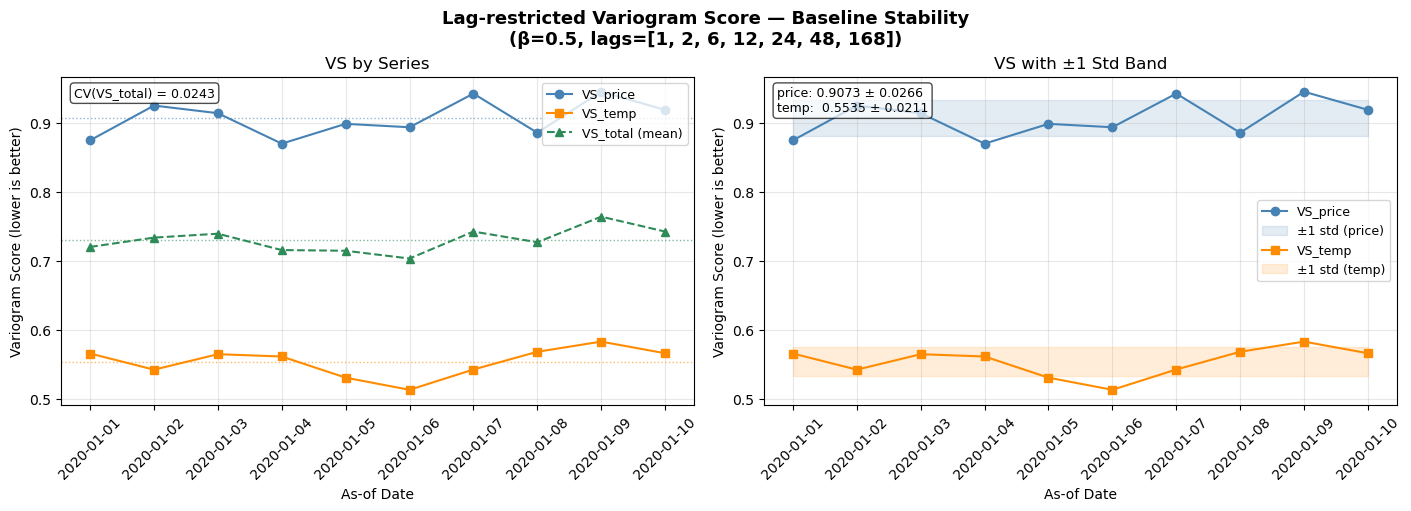

In [43]:
# ============================================================
# STEP 10: Visualization — VS_total across as-of dates
# ============================================================

import matplotlib.dates as mdates

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         constrained_layout=True)

fig.suptitle(
    "Lag-restricted Variogram Score — Baseline Stability\n"
    f"(β={beta_main}, lags={lags_main})",
    fontsize=13, fontweight='bold'
)

dates = vs_df['asof'].dt.date

# --- Left panel: VS by series ---
ax = axes[0]
ax.plot(dates, vs_df['vs_price'],
        marker='o', linewidth=1.5, color='steelblue',
        label='VS_price')
ax.plot(dates, vs_df['vs_temp'],
        marker='s', linewidth=1.5, color='darkorange',
        label='VS_temp')
ax.plot(dates, vs_df['vs_total'],
        marker='^', linewidth=1.5, color='seagreen',
        linestyle='--', label='VS_total (mean)')

# Reference lines: mean per series
ax.axhline(vs_df['vs_price'].mean(), color='steelblue',
           linestyle=':', linewidth=1.0, alpha=0.6)
ax.axhline(vs_df['vs_temp'].mean(),  color='darkorange',
           linestyle=':', linewidth=1.0, alpha=0.6)
ax.axhline(vs_df['vs_total'].mean(), color='seagreen',
           linestyle=':', linewidth=1.0, alpha=0.6)

ax.set_title("VS by Series")
ax.set_xlabel("As-of Date")
ax.set_ylabel("Variogram Score (lower is better)")
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Annotate CV
cv_total = vs_df['vs_total'].std() / vs_df['vs_total'].mean()
ax.text(0.02, 0.97,
        f"CV(VS_total) = {cv_total:.4f}",
        transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# --- Right panel: VS_price and VS_temp with ±1 std band ---
ax2 = axes[1]

mean_p = vs_df['vs_price'].mean()
std_p  = vs_df['vs_price'].std()
mean_t = vs_df['vs_temp'].mean()
std_t  = vs_df['vs_temp'].std()

ax2.plot(dates, vs_df['vs_price'],
         marker='o', linewidth=1.5, color='steelblue',
         label='VS_price')
ax2.fill_between(dates,
                 mean_p - std_p, mean_p + std_p,
                 color='steelblue', alpha=0.15,
                 label='±1 std (price)')

ax2.plot(dates, vs_df['vs_temp'],
         marker='s', linewidth=1.5, color='darkorange',
         label='VS_temp')
ax2.fill_between(dates,
                 mean_t - std_t, mean_t + std_t,
                 color='darkorange', alpha=0.15,
                 label='±1 std (temp)')

ax2.set_title("VS with ±1 Std Band")
ax2.set_xlabel("As-of Date")
ax2.set_ylabel("Variogram Score (lower is better)")
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Annotate mean ± std
ax2.text(0.02, 0.97,
         f"price: {mean_p:.4f} ± {std_p:.4f}\n"
         f"temp:  {mean_t:.4f} ± {std_t:.4f}",
         transform=ax2.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.show()

In [48]:

# ============================================================
# STEP 11-13: Violation Rate, Interval Width, Tail Exceedance
# Part 1: Parameter Setup
# ============================================================

# --- Quantile definitions ---
q_low_90,  q_high_90  = 0.05,  0.95
q_low_95,  q_high_95  = 0.025, 0.975
q_tail_lo, q_tail_hi  = 0.01,  0.99   # VaR-style tails

# --- Lead-time buckets (0-based internal indexing) ---
# horizons: 0..8759 corresponds to lead-time hours 1..8760
buckets = {
    "intraday":  (0, 24),     # lead-time 1..24
    "weekly":    (24, 168),   # lead-time 25..168
    "monthly":   (168, 720),  # lead-time 169..720
    #"long_term": (720, 8760)  # lead-time 721..8760
}

# H = 8760
H = 720
horizons = np.arange(H)  # 0..8759

def get_bucket_mask(horizons, low_inclusive, high_exclusive):
    """
    horizons: 0-based array [0..H-1], corresponding to lead-time hours [1..H]
    Bucket definition uses 0-based indexing internally:
      horizons in [low_inclusive, high_exclusive)
    Example:
      [0, 24) -> lead-time hours 1..24
    """
    return (horizons >= low_inclusive) & (horizons < high_exclusive)

bucket_masks = {
    name: get_bucket_mask(horizons, low, high)
    for name, (low, high) in buckets.items()
}

# Verify coverage (no gaps, no overlaps)
total_covered = sum(mask.sum() for mask in bucket_masks.values())
assert total_covered == H, f"Bucket coverage error: {total_covered} != {H}"

# Optional: verify disjointness (overlap check)
overlap_count = np.sum(np.stack(list(bucket_masks.values()), axis=0), axis=0)
assert np.all(overlap_count == 1), "Bucket overlap or gap detected (some horizons not assigned exactly once)."

print("Parameter Setup")
print("="*55)
print("Quantiles:")
print(f"  90% interval : [{q_low_90},  {q_high_90}]")
print(f"  95% interval : [{q_low_95}, {q_high_95}]")
print(f"  Tail lower   : q={q_tail_lo}  (y < q_0.01)")
print(f"  Tail upper   : q={q_tail_hi}  (y > q_0.99)")
print()
print("Lead-time buckets (hours since as-of):")
print(f"  {'Bucket':<12} {'Range':<18} {'n_horizons':>10}")
print("-"*45)
for name, (low, high) in buckets.items():
    n = bucket_masks[name].sum()
    # Convert 0-based [low, high) into 1-based [low+1, high]
    print(f"  {name:<12} h in [{low+1:>4}, {high:>4}] {n:>10}")
print("-"*45)
print(f"  {'Total':<12} {'':<18} {total_covered:>10}")

Parameter Setup
Quantiles:
  90% interval : [0.05,  0.95]
  95% interval : [0.025, 0.975]
  Tail lower   : q=0.01  (y < q_0.01)
  Tail upper   : q=0.99  (y > q_0.99)

Lead-time buckets (hours since as-of):
  Bucket       Range              n_horizons
---------------------------------------------
  intraday     h in [   1,   24]         24
  weekly       h in [  25,  168]        144
  monthly      h in [ 169,  720]        552
---------------------------------------------
  Total                                  720


In [49]:
# ============================================================
# STEP 11-13: Core Function to Compute Metrics by Bucket
# ============================================================

import warnings

def compute_coverage_metrics(sims, realized, bucket_masks,
                              q_low_90,  q_high_90,
                              q_low_95,  q_high_95,
                              q_tail_lo, q_tail_hi,
                              check_finite=False,
                              expect_H=None,
                              auto_orient=True):
    """
    Compute violation rate, interval width, and tail exceedance
    for a single as-of date, reported by lead-time bucket.

    Parameters
    ----------
    sims         : array-like, shape (H, N) or (N, H)
                   Simulated paths. Auto-oriented to (H, N) if
                   auto_orient=True.
    realized     : array-like, shape (H,)
                   Realized values
    bucket_masks : dict of {str: bool array (H,)}
                   Lead-time bucket masks
    q_low_90/q_high_90   : float — 90% interval quantiles
    q_low_95/q_high_95   : float — 95% interval quantiles
    q_tail_lo/q_tail_hi  : float — tail exceedance quantiles
    check_finite : bool — check for NaN/inf (single-point only)
    expect_H     : int or None — expected horizon dimension.
                   If provided, used to orient sims unambiguously.
                   Recommended: always pass expect_H=H explicitly.
    auto_orient  : bool — if True, auto-transpose sims if needed.

    Returns
    -------
    results : dict of {bucket_name: dict of metrics}
        Each bucket contains:
            viol_90    : violation rate, 90% interval
                         (nominal = 0.10 under correct spec)
            viol_95    : violation rate, 95% interval
                         (nominal = 0.05 under correct spec)
            width_90   : mean interval width, 90%
            width_95   : mean interval width, 95%
            exceed_lo  : lower tail exceedance (nominal = 0.01)
            exceed_hi  : upper tail exceedance (nominal = 0.01)
            n_horizons : number of horizons in bucket
    """

    # --- Type coercion ---
    sims     = np.asarray(sims,     dtype=float)
    realized = np.asarray(realized, dtype=float)

    # --- Shape checks ---
    if sims.ndim != 2:
        raise ValueError(
            f"sims must be 2D, got shape {sims.shape}")
    if realized.ndim != 1:
        raise ValueError(
            f"realized must be 1D, got shape {realized.shape}")

    # --- Auto-orient sims to (H, N) ---
    if auto_orient:
        if expect_H is not None:
            # Unambiguous: use expect_H
            if sims.shape[0] != expect_H and sims.shape[1] == expect_H:
                sims = sims.T
        else:
            # Heuristic: match realized length
            if sims.shape[0] == sims.shape[1]:
                warnings.warn(
                    f"sims is square ({sims.shape}); "
                    f"cannot auto-orient — pass expect_H explicitly."
                )
            elif (sims.shape[0] != realized.shape[0] and
                  sims.shape[1] == realized.shape[0]):
                sims = sims.T

    H, N = sims.shape

    if realized.shape[0] != H:
        raise ValueError(
            f"realized length {realized.shape[0]} != sims H {H}")

    # --- Optional finite check ---
    if check_finite:
        if not np.isfinite(sims).all():
            raise ValueError("non-finite values in sims")
        if not np.isfinite(realized).all():
            raise ValueError("non-finite values in realized")

    # --- Compute quantile bounds: shape (H,) ---
    lo_90   = np.quantile(sims, q_low_90,  axis=1) 
    hi_90   = np.quantile(sims, q_high_90, axis=1)
    lo_95   = np.quantile(sims, q_low_95,  axis=1)
    hi_95   = np.quantile(sims, q_high_95, axis=1)
    lo_tail = np.quantile(sims, q_tail_lo, axis=1)
    hi_tail = np.quantile(sims, q_tail_hi, axis=1)

    # --- Boolean arrays: shape (H,) ---
    viol_90_arr   = (realized < lo_90)  | (realized > hi_90)
    viol_95_arr   = (realized < lo_95)  | (realized > hi_95)
    exceed_lo_arr = (realized < lo_tail)
    exceed_hi_arr = (realized > hi_tail)
    width_90_arr  = hi_90 - lo_90
    width_95_arr  = hi_95 - lo_95

    # --- Aggregate by bucket ---
    results = {}

    for bucket_name, mask in bucket_masks.items():
        mask = np.asarray(mask, dtype=bool)

        if mask.shape[0] != H:
            raise ValueError(
                f"bucket mask '{bucket_name}' length "
                f"{mask.shape[0]} != H {H}")

        n = int(mask.sum())
        if n == 0:
            continue

        results[bucket_name] = {
            "viol_90":    float(viol_90_arr[mask].mean()),
            "viol_95":    float(viol_95_arr[mask].mean()),
            "width_90":   float(width_90_arr[mask].mean()),
            "width_95":   float(width_95_arr[mask].mean()),
            "exceed_lo":  float(exceed_lo_arr[mask].mean()),
            "exceed_hi":  float(exceed_hi_arr[mask].mean()),
            "n_horizons": n,
        }

    return results

In [50]:
# ============================================================
# STEP 11-13: Single-point Validation 
# Part 3: Single As-of Date
# ============================================================

asof_test = asof_dates[0]

sims_p = sims_dict[asof_test]['price'].values
sims_t = sims_dict[asof_test]['temp'].values
real_p = realized_dict['price'].loc[asof_test].values
real_t = realized_dict['temp'].loc[asof_test].values

results_p = compute_coverage_metrics(
    sims_p, real_p, bucket_masks,
    q_low_90, q_high_90,
    q_low_95, q_high_95,
    q_tail_lo, q_tail_hi,
    check_finite=True, expect_H=H
)

results_t = compute_coverage_metrics(
    sims_t, real_t, bucket_masks,
    q_low_90, q_high_90,
    q_low_95, q_high_95,
    q_tail_lo, q_tail_hi,
    check_finite=True, expect_H=H
)

bucket_order = ["intraday", "weekly", "monthly", "long_term"]

for series_name, results in [('price', results_p),
                              ('temp',  results_t)]:

    # --- Weighted overall ---
    total_h = sum(m['n_horizons'] for m in results.values())

    def wavg(key):
        return sum(
            m[key] * m['n_horizons']
            for m in results.values()
        ) / total_h

    print()
    print("="*72)
    print(f"Single as-of Validation: {asof_test.date()}  |  "
          f"Series: {series_name}")
    print("Nominal rates under correct specification: "
          "viol_90=0.10, viol_95=0.05, "
          "exceed_lo=0.01, exceed_hi=0.01")
    print("="*72)
    print(f"  {'Bucket':<12} {'n_h':>5}  "
          f"{'viol_90':>8} {'viol_95':>8}  "
          f"{'width_90':>9} {'width_95':>9}  "
          f"{'exc_lo':>7} {'exc_hi':>7}")
    print("-"*72)

    for bucket_name in bucket_order:
        m = results.get(bucket_name)

        # Defensive: bucket skipped (e.g. n_horizons=0)
        if m is None:
            print(f"  {bucket_name:<12} {'-':>5}  "
                  f"{'-':>8} {'-':>8}  "
                  f"{'-':>9} {'-':>9}  "
                  f"{'-':>7} {'-':>7}")
            continue

        print(f"  {bucket_name:<12} {m['n_horizons']:>5}  "
              f"{m['viol_90']:>8.4f} {m['viol_95']:>8.4f}  "
              f"{m['width_90']:>9.4f} {m['width_95']:>9.4f}  "
              f"{m['exceed_lo']:>7.4f} {m['exceed_hi']:>7.4f}")

    print("-"*72)

    print(f"  {'overall':<12} {total_h:>5}  "
          f"{wavg('viol_90'):>8.4f} {wavg('viol_95'):>8.4f}  "
          f"{wavg('width_90'):>9.4f} {wavg('width_95'):>9.4f}  "
          f"{wavg('exceed_lo'):>7.4f} {wavg('exceed_hi'):>7.4f}")


Single as-of Validation: 2020-01-01  |  Series: price
Nominal rates under correct specification: viol_90=0.10, viol_95=0.05, exceed_lo=0.01, exceed_hi=0.01
  Bucket         n_h   viol_90  viol_95   width_90  width_95   exc_lo  exc_hi
------------------------------------------------------------------------
  intraday        24    0.0833   0.0833    16.5273   19.6728   0.0000  0.0417
  weekly         144    0.0972   0.0486    16.4297   19.5540   0.0000  0.0139
  monthly        552    0.1014   0.0471    16.3007   19.3567   0.0109  0.0072
  long_term        -         -        -          -         -        -       -
------------------------------------------------------------------------
  overall        720    0.1000   0.0486    16.3340   19.4067   0.0083  0.0097

Single as-of Validation: 2020-01-01  |  Series: temp
Nominal rates under correct specification: viol_90=0.10, viol_95=0.05, exceed_lo=0.01, exceed_hi=0.01
  Bucket         n_h   viol_90  viol_95   width_90  width_95   exc_lo  ex

In [51]:
# ============================================================
# STEP 11-13: Full Evaluation 
# Part 4: Full Run
# ============================================================

import time

def weighted_overall(res):
    """
    Compute horizon-weighted overall metrics from bucket results.
    Raises ValueError if total_h == 0.
    """
    total_h = sum(m['n_horizons'] for m in res.values())
    if total_h == 0:
        raise ValueError(
            "total_h is 0: empty bucket results "
            "(check bucket_masks and H).")
    keys = ['viol_90', 'viol_95', 'width_90',
            'width_95', 'exceed_lo', 'exceed_hi']
    return {
        k: sum(m[k] * m['n_horizons']
               for m in res.values()) / total_h
        for k in keys
    }, total_h


def wmean(df, col, wcol='n_horizons'):
    """Horizon-weighted mean of col in df."""
    w = df[wcol].to_numpy()
    x = df[col].to_numpy()
    return float(np.sum(x * w) / np.sum(w))


# --- Storage ---
detail_results  = []   # asof × series × bucket
overall_results = []   # asof × series × overall

nominal_map = {
    'viol_90':   0.10,
    'viol_95':   0.05,
    'exceed_lo': 0.01,
    'exceed_hi': 0.01,
    'width_90':  None,
    'width_95':  None,
}

print("="*72)
print("Full Evaluation: all as-of dates")
print("="*72)

for asof in asof_dates:
    t_start = time.time()

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    res_p = compute_coverage_metrics(
        sims_p, real_p, bucket_masks,
        q_low_90, q_high_90,
        q_low_95, q_high_95,
        q_tail_lo, q_tail_hi,
        check_finite=False, expect_H=H
    )
    res_t = compute_coverage_metrics(
        sims_t, real_t, bucket_masks,
        q_low_90, q_high_90,
        q_low_95, q_high_95,
        q_tail_lo, q_tail_hi,
        check_finite=False, expect_H=H
    )

    for series_name, res in [('price', res_p), ('temp', res_t)]:

        # --- Detail: by bucket ---
        for bucket_name in bucket_order:
            m = res.get(bucket_name)
            if m is None:
                continue
            detail_results.append({
                'asof':       asof,
                'series':     series_name,
                'bucket':     bucket_name,
                'viol_90':    m['viol_90'],
                'viol_95':    m['viol_95'],
                'width_90':   m['width_90'],
                'width_95':   m['width_95'],
                'exceed_lo':  m['exceed_lo'],
                'exceed_hi':  m['exceed_hi'],
                'n_horizons': m['n_horizons'],
            })

        # --- Overall: horizon-weighted ---
        ov, total_h = weighted_overall(res)
        overall_results.append({
            'asof':       asof,
            'series':     series_name,
            'n_horizons': total_h,
            **ov
        })

    t_elapsed = time.time() - t_start
    print(f"  {asof.date()}  ({t_elapsed:.2f}s)")

detail_df  = pd.DataFrame(detail_results)
overall_df = pd.DataFrame(overall_results)

# Add deviation columns to overall_df
for k, nom in nominal_map.items():
    if nom is not None and k in overall_df.columns:
        overall_df[f"{k}_dev"] = overall_df[k] - nom

# ============================================================
# Summary: overall by series
# ============================================================
metrics_to_report = ['viol_90', 'viol_95',
                     'width_90', 'width_95',
                     'exceed_lo', 'exceed_hi']

for series_name in ['price', 'temp']:
    df_s = overall_df[overall_df['series'] == series_name]

    print()
    print("="*72)
    print(f"Summary (overall, horizon-weighted): {series_name}")
    print("="*72)
    print(f"  {'Metric':<12} {'Mean':>8} {'Std':>8} "
          f"{'Min':>8} {'Max':>8}  "
          f"{'Nominal':>8} {'Mean Dev':>9}")
    print("-"*68)

    for col in metrics_to_report:
        mean = df_s[col].mean()
        std  = df_s[col].std()
        mn   = df_s[col].min()
        mx   = df_s[col].max()
        nom  = nominal_map[col]
        nom_str = f"{nom:.2f}" if nom is not None else "n/a"
        dev_str = f"{mean - nom:+.4f}" if nom is not None else "n/a"

        print(f"  {col:<12} {mean:>8.4f} {std:>8.4f} "
              f"{mn:>8.4f} {mx:>8.4f}  "
              f"{nom_str:>8} {dev_str:>9}")

# ============================================================
# Summary: by bucket (averaged across as-of dates)
# ============================================================
for series_name in ['price', 'temp']:
    df_s = detail_df[detail_df['series'] == series_name]

    print()
    print("="*72)
    print(f"Summary (by bucket): {series_name}")
    print("="*72)
    print(f"  {'Bucket':<12} {'n_h':>5}  "
          f"{'viol_90':>8} {'viol_95':>8}  "
          f"{'width_90':>9} {'width_95':>9}  "
          f"{'exc_lo':>7} {'exc_hi':>7}")
    print("-"*72)

    for bucket_name in bucket_order:
        df_b = df_s[df_s['bucket'] == bucket_name]
        if df_b.empty:
            continue

        # Assert n_horizons is constant across as-of dates
        assert df_b['n_horizons'].nunique() == 1, (
            f"n_horizons varies across as-of dates "
            f"for bucket '{bucket_name}' — check bucket_masks."
        )
        n_h = int(df_b['n_horizons'].iloc[0])

        print(f"  {bucket_name:<12} {n_h:>5}  "
              f"{wmean(df_b, 'viol_90'):>8.4f} "
              f"{wmean(df_b, 'viol_95'):>8.4f}  "
              f"{wmean(df_b, 'width_90'):>9.4f} "
              f"{wmean(df_b, 'width_95'):>9.4f}  "
              f"{wmean(df_b, 'exceed_lo'):>7.4f} "
              f"{wmean(df_b, 'exceed_hi'):>7.4f}")

Full Evaluation: all as-of dates
  2020-01-01  (0.06s)
  2020-01-02  (0.05s)
  2020-01-03  (0.05s)
  2020-01-04  (0.05s)
  2020-01-05  (0.09s)
  2020-01-06  (0.05s)
  2020-01-07  (0.05s)
  2020-01-08  (0.05s)
  2020-01-09  (0.05s)
  2020-01-10  (0.06s)

Summary (overall, horizon-weighted): price
  Metric           Mean      Std      Min      Max   Nominal  Mean Dev
--------------------------------------------------------------------
  viol_90        0.0993   0.0124   0.0833   0.1250      0.10   -0.0007
  viol_95        0.0508   0.0089   0.0417   0.0708      0.05   +0.0008
  width_90      16.3542   0.0285  16.3276  16.4204       n/a       n/a
  width_95      19.4207   0.0311  19.3724  19.4711       n/a       n/a
  exceed_lo      0.0108   0.0033   0.0056   0.0153      0.01   +0.0008
  exceed_hi      0.0104   0.0054   0.0042   0.0222      0.01   +0.0004

Summary (overall, horizon-weighted): temp
  Metric           Mean      Std      Min      Max   Nominal  Mean Dev
-----------------------

## PART 2: POWER ANALYSIS + STRESS TESTING:

In [52]:
print(type(sims_dict))
print(len(sims_dict))
print(list(sims_dict.keys())[:3])

<class 'dict'>
10
[Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-02 00:00:00'), Timestamp('2020-01-03 00:00:00')]


In [ ]:


"""X' = X_F + δ · s_v
where s_v is the vector of per-horizon standard deviations of the original simulations, and δ is a scalar perturbation factor. 
By varying δ, we can create a family of perturbed simulation sets that deviate from the original in a controlled manner.
For example, we can choose δ values such as [0.0, 0.5, 1.0, 1.5, 2.0], where:
- δ=0.0 corresponds to the original simulations (no perturbation).  
- δ=0.5 corresponds to a mild perturbation, where we add half of the standard deviation to each horizon.
- δ=1.0 corresponds to a moderate perturbation, where we add the full standard deviation to each horizon.
- δ=1.5 corresponds to a strong perturbation, where we add 1.5 times the standard deviation to each horizon.
- δ=2.0 corresponds to a very strong perturbation, where we add twice the standard deviation to each horizon.
By evaluating the lag-variogram score on these perturbed simulation sets, we can analyze how the score changes as the simulations deviate from the original, 
providing insights into the sensitivity of the score to simulation quality and the robustness of our evaluation framework."""

deltas = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
T1_results = []

for delta in deltas:
    
    # 1. To build shifted forecastings, we add δ times the standard deviation to the original simulations
    sims_dict_t1 = {}
    for asof in asof_dates:
        sims_dict_t1[asof] = {
            'price': sims_dict[asof]['price'].copy() + delta * std_price,
            'temp':  sims_dict[asof]['temp'].copy()  + delta * std_temp
        }
    
    # 2. Energy Score
    es_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t1[asof]['price'].values
        sims_t = sims_dict_t1[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        es_val, _, _ = energy_score(
            sims_p, sims_t, real_p, real_t,
            mu_price, std_price, mu_temp, std_temp,
            M=500, R=5, seed=42
        )
        es_list.append(es_val)

    # 3. Variogram Score
    vs_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t1[asof]['price'].values
        sims_t = sims_dict_t1[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        vs_p, _ = lag_variogram_score(sims_p, real_p, lags_main, w_norm, beta=beta_main)
        vs_t, _ = lag_variogram_score(sims_t, real_t, lags_main, w_norm, beta=beta_main)
        vs_list.append(0.5 * (vs_p + vs_t))

    # 4. Coverage metrics
    viol90_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t1[asof]['price'].values
        real_p = realized_dict['price'].loc[asof].values

        res_p = compute_coverage_metrics(
            sims_p, real_p, bucket_masks,
            q_low_90, q_high_90,
            q_low_95, q_high_95,
            q_tail_lo, q_tail_hi,
            check_finite=False, expect_H=H
        )
        ov_p, _ = weighted_overall(res_p)
        viol90_list.append(ov_p['viol_90'])

    T1_results.append({
        'delta':           delta,
        'ES_mean':         np.mean(es_list),
        'VS_mean':         np.mean(vs_list),
        'viol90_mean':     np.mean(viol90_list),
    })

    print(f"δ={delta:.2f}  ES={np.mean(es_list):.4f}  VS={np.mean(vs_list):.6f}  viol90={np.mean(viol90_list):.4f}")

T1_df = pd.DataFrame(T1_results)
print()
print(T1_df.to_string(index=False))

δ=0.00  ES=15.0382  VS=0.730423  viol90=0.0993
δ=0.25  ES=16.5330  VS=0.730423  viol90=0.1269
δ=0.50  ES=20.5707  VS=0.730423  viol90=0.2010
δ=0.75  ES=26.4187  VS=0.730423  viol90=0.3228
δ=1.00  ES=33.4286  VS=0.730423  viol90=0.4675
δ=1.50  ES=49.3767  VS=0.730423  viol90=0.7544
δ=2.00  ES=66.6271  VS=0.730423  viol90=0.9272

 delta   ES_mean  VS_mean  viol90_mean
  0.00 15.038229 0.730423     0.099306
  0.25 16.533021 0.730423     0.126944
  0.50 20.570689 0.730423     0.200972
  0.75 26.418662 0.730423     0.322778
  1.00 33.428585 0.730423     0.467500
  1.50 49.376656 0.730423     0.754444
  2.00 66.627101 0.730423     0.927222


In [1]:
"""Type2: spread rescaling X' = μ_t + γ(X_F − μ_t), con γ ∈ {0.5, 0.75, 1.25, 1.5, 2.0}
This transformation rescales the deviations of the forecasts from the mean by a factor γ, effectively controlling the spread of the simulations around
the mean. By varying γ, we can create a family of perturbed simulation sets that are either more concentrated (γ < 1) or more dispersed (γ > 1) around
the mean, allowing us to analyze how the lag-variogram score responds to changes in the spread of the simulations. For example, we can choose γ values
such as [0.5, 0.75, 1.0, 1.25, 1.5, 2.0], where:
- γ=0.5 corresponds to a strong concentration, where the simulations are pulled halfway towards the mean, resulting in a narrower spread.
- γ=0.75 corresponds to a mild concentration, where the simulations are pulled 25% towards the mean, resulting in a moderately narrower spread.
- γ=1.0 corresponds to the original simulations (no rescaling).
- γ=1.25 corresponds to a mild dispersion, where the simulations are pushed 25% away from the mean, resulting in a moderately wider spread.
- γ=1.5 corresponds to a strong dispersion, where the simulations are pushed 50% away from the mean, resulting in a wider spread.
- γ=2.0 corresponds to a very strong dispersion, where the simulations are pushed twice as far from the mean, resulting in a very wide spread."""
gammas = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
T2_results = []

for gamma in gammas:
    
    # 1. To build shifted forecastings, we add δ times the standard deviation to the original simulations
    sims_dict_t2 = {}
    for asof in asof_dates:
        sims_dict_t2[asof] = {
            'price': mu_price + gamma * (sims_dict[asof]['price'].copy() - mu_price),
            'temp':  mu_temp + gamma * (sims_dict[asof]['temp'].copy() - mu_temp)
        }
    
    # 2. Energy Score
    es_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t2[asof]['price'].values
        sims_t = sims_dict_t2[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        es_val, _, _ = energy_score(
            sims_p, sims_t, real_p, real_t,
            mu_price, std_price, mu_temp, std_temp,
            M=500, R=5, seed=42
        )
        es_list.append(es_val)

    # 3. Variogram Score
    vs_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t2[asof]['price'].values
        sims_t = sims_dict_t2[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        vs_p, _ = lag_variogram_score(sims_p, real_p, lags_main, w_norm, beta=beta_main)
        vs_t, _ = lag_variogram_score(sims_t, real_t, lags_main, w_norm, beta=beta_main)
        vs_list.append(0.5 * (vs_p + vs_t))

    # 4. Coverage metrics
    viol90_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t2[asof]['price'].values
        real_p = realized_dict['price'].loc[asof].values

        res_p = compute_coverage_metrics(
            sims_p, real_p, bucket_masks,
            q_low_90, q_high_90,
            q_low_95, q_high_95,
            q_tail_lo, q_tail_hi,
            check_finite=False, expect_H=H
        )
        ov_p, _ = weighted_overall(res_p)
        viol90_list.append(ov_p['viol_90'])

    T2_results.append({
        'gamma':           gamma,
        'ES_mean':         np.mean(es_list),
        'VS_mean':         np.mean(vs_list),
        'viol90_mean':     np.mean(viol90_list),
    })

    print(f"γ={gamma:.2f}  ES={np.mean(es_list):.4f}  VS={np.mean(vs_list):.6f}  viol90={np.mean(viol90_list):.4f}")


T2_df = pd.DataFrame(T2_results)
print()
print(T2_df.to_string(index=False))

NameError: name 'asof_dates' is not defined

In [ ]:
"""Tail mispecification: ε^(t) = c_v · T_v · c_v, con ν ∈ {3, 5, 10, 30}"""
nis = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
T4_results = []

for ni in nis:
    
    # 1. To build shifted forecastings, we add δ times the standard deviation to the original simulations
    sims_dict_t4 = {}
    for asof in asof_dates:
        sims_dict_t4[asof] = {
            'price': mu_price + ni * (sims_dict[asof]['price'].copy() - mu_price),
            'temp':  mu_temp + ni * (sims_dict[asof]['temp'].copy() - mu_temp)
        }
    
    # 2. Energy Score
    es_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t2[asof]['price'].values
        sims_t = sims_dict_t2[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        es_val, _, _ = energy_score(
            sims_p, sims_t, real_p, real_t,
            mu_price, std_price, mu_temp, std_temp,
            M=500, R=5, seed=42
        )
        es_list.append(es_val)

    # 3. Variogram Score
    vs_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t2[asof]['price'].values
        sims_t = sims_dict_t2[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        vs_p, _ = lag_variogram_score(sims_p, real_p, lags_main, w_norm, beta=beta_main)
        vs_t, _ = lag_variogram_score(sims_t, real_t, lags_main, w_norm, beta=beta_main)
        vs_list.append(0.5 * (vs_p + vs_t))

    # 4. Coverage metrics
    viol90_list = []
    for asof in asof_dates:
        sims_p = sims_dict_t2[asof]['price'].values
        real_p = realized_dict['price'].loc[asof].values

        res_p = compute_coverage_metrics(
            sims_p, real_p, bucket_masks,
            q_low_90, q_high_90,
            q_low_95, q_high_95,
            q_tail_lo, q_tail_hi,
            check_finite=False, expect_H=H
        )
        ov_p, _ = weighted_overall(res_p)
        viol90_list.append(ov_p['viol_90'])

    T2_results.append({
        'gamma':           gamma,
        'ES_mean':         np.mean(es_list),
        'VS_mean':         np.mean(vs_list),
        'viol90_mean':     np.mean(viol90_list),
    })

    print(f"γ={gamma:.2f}  ES={np.mean(es_list):.4f}  VS={np.mean(vs_list):.6f}  viol90={np.mean(viol90_list):.4f}")


T2_df = pd.DataFrame(T2_results)
print()
print(T2_df.to_string(index=False))
